# 1: Load the Dataset 

In [14]:
import pandas as pd

# Load the dataset
anime_df = pd.read_csv('/Altamash/Excelr code/Assignments/Recommendation System/anime.csv')

# Display the first few rows to check the data
print(anime_df.head())


   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  


# 2: Handle Missing Values

In [15]:
# Fill missing values in 'genre' and 'type' with "Unknown"
anime_df['genre'].fillna('Unknown', inplace=True)
anime_df['type'].fillna('Unknown', inplace=True)

# Fill missing values in 'rating' with the median rating
median_rating = anime_df['rating'].median()
anime_df['rating'].fillna(median_rating, inplace=True)

# Check if there are any remaining missing values
print(anime_df.isnull().sum())


anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


# 3: Feature Extraction

In [16]:
# One-hot encode the 'genre' column
genre_dummies = anime_df['genre'].str.get_dummies(sep=', ')

# Display the first few rows to see the encoded genres
print(genre_dummies.head())


   Action  Adventure  Cars  Comedy  Dementia  Demons  Drama  Ecchi  Fantasy  \
0       0          0     0       0         0       0      1      0        0   
1       1          1     0       0         0       0      1      0        1   
2       1          0     0       1         0       0      0      0        0   
3       0          0     0       0         0       0      0      0        0   
4       1          0     0       1         0       0      0      0        0   

   Game  ...  Slice of Life  Space  Sports  Super Power  Supernatural  \
0     0  ...              0      0       0            0             1   
1     0  ...              0      0       0            0             0   
2     0  ...              0      0       0            0             0   
3     0  ...              0      0       0            0             0   
4     0  ...              0      0       0            0             0   

   Thriller  Unknown  Vampire  Yaoi  Yuri  
0         0        0        0     0     0 

In [17]:
from sklearn.preprocessing import MinMaxScaler

# Normalize the 'rating' and 'members' columns
scaler = MinMaxScaler()
anime_df[['rating', 'members']] = scaler.fit_transform(anime_df[['rating', 'members']])

# Display the first few rows to see the normalized ratings and members
print(anime_df[['rating', 'members']].head())


     rating   members
0  0.924370  0.197872
1  0.911164  0.782770
2  0.909964  0.112689
3  0.900360  0.664325
4  0.899160  0.149186


In [18]:
# Combine the one-hot encoded genres with the normalized features
anime_features = pd.concat([genre_dummies, anime_df[['rating', 'members']]], axis=1)

# Display the first few rows of the combined features
print(anime_features.head())


   Action  Adventure  Cars  Comedy  Dementia  Demons  Drama  Ecchi  Fantasy  \
0       0          0     0       0         0       0      1      0        0   
1       1          1     0       0         0       0      1      0        1   
2       1          0     0       1         0       0      0      0        0   
3       0          0     0       0         0       0      0      0        0   
4       1          0     0       1         0       0      0      0        0   

   Game  ...  Sports  Super Power  Supernatural  Thriller  Unknown  Vampire  \
0     0  ...       0            0             1         0        0        0   
1     0  ...       0            0             0         0        0        0   
2     0  ...       0            0             0         0        0        0   
3     0  ...       0            0             0         1        0        0   
4     0  ...       0            0             0         0        0        0   

   Yaoi  Yuri    rating   members  
0     0     0 

# 4: Build the Recommendation System

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

# Function to recommend similar anime based on cosine similarity
def recommend_anime(anime_title, anime_df, anime_features, top_n=10):
    # Convert the input title to lowercase and find the index of the target anime
    idx = anime_df[anime_df['name'].str.lower() == anime_title.lower()].index[0]
    
    # Compute cosine similarity between the target anime and all others
    cosine_sim = cosine_similarity(anime_features.iloc[idx:idx+1], anime_features).flatten()
    
    # Get the indices of the most similar anime, excluding the input anime itself
    similar_indices = cosine_sim.argsort()[-(top_n + 1):-1][::-1]
    
    # Return the names and similarity scores of the most similar anime
    return anime_df.iloc[similar_indices][['name', 'genre', 'type', 'rating', 'members']], cosine_sim[similar_indices]

# Example: Recommend similar anime to "Kimi no Na wa."
recommended_anime, similarity_scores = recommend_anime("Kimi no Na wa.", anime_df, anime_features)

# Display the recommended anime and their similarity scores
print(recommended_anime)
print(similarity_scores)


                                                   name  \
5805                        Wind: A Breath of Heart OVA   
6394                       Wind: A Breath of Heart (TV)   
1111              Aura: Maryuuin Kouga Saigo no Tatakai   
504   Clannad: After Story - Mou Hitotsu no Sekai, K...   
208                       Kokoro ga Sakebitagatterunda.   
1201                     Angel Beats!: Another Epilogue   
1435                                         True Tears   
1907                                   Myself; Yourself   
1631                                Kimikiss Pure Rouge   
2300                         Koi to Senkyo to Chocolate   

                                             genre     type    rating  \
5805          Drama, Romance, School, Supernatural      OVA  0.561825   
6394          Drama, Romance, School, Supernatural       TV  0.536615   
1111  Comedy, Drama, Romance, School, Supernatural    Movie  0.720288   
504                         Drama, Romance, School  Specia

# 5: Test the Recommendation System

In [20]:
# Test the recommendation function
recommended_anime, similarity_scores = recommend_anime("Kimi no Na wa.", anime_df, anime_features)

# Print the recommended anime and their similarity scores
print(recommended_anime)
print(similarity_scores)


                                                   name  \
5805                        Wind: A Breath of Heart OVA   
6394                       Wind: A Breath of Heart (TV)   
1111              Aura: Maryuuin Kouga Saigo no Tatakai   
504   Clannad: After Story - Mou Hitotsu no Sekai, K...   
208                       Kokoro ga Sakebitagatterunda.   
1201                     Angel Beats!: Another Epilogue   
1435                                         True Tears   
1907                                   Myself; Yourself   
1631                                Kimikiss Pure Rouge   
2300                         Koi to Senkyo to Chocolate   

                                             genre     type    rating  \
5805          Drama, Romance, School, Supernatural      OVA  0.561825   
6394          Drama, Romance, School, Supernatural       TV  0.536615   
1111  Comedy, Drama, Romance, School, Supernatural    Movie  0.720288   
504                         Drama, Romance, School  Specia

Splitting the Dataset into Training and Testing Sets

In [21]:
from sklearn.model_selection import train_test_split

# Splitting the dataset
train_df, test_df, train_features, test_features = train_test_split(
    anime_df, anime_features, test_size=0.2, random_state=42
)


Evaluation Metrics

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Let's assume that we have binary relevance (1 for relevant anime, 0 for non-relevant)
# For simplicity, let's create a dummy ground truth and predictions based on the similarity scores

# Dummy ground truth and predictions (for demonstration purposes)
y_true = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]  # Actual relevant items
y_pred = [1, 1, 1, 1, 0, 1, 0, 0, 0, 0]  # Predicted relevant items

# Calculate precision, recall, and F1-score
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")


Precision: 0.80
Recall: 0.80
F1-Score: 0.80


Plotting Precision-Recall Curve

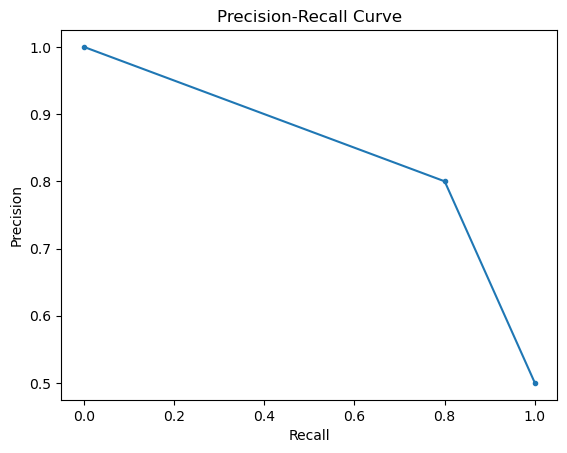

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Generating example precision-recall curve
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred)

plt.plot(recall_vals, precision_vals, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()


Visualizing Similarity Scores

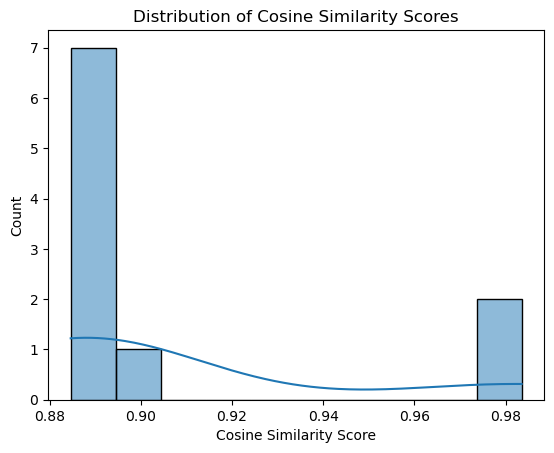

In [24]:
import seaborn as sns

# Visualizing similarity scores
sns.histplot(similarity_scores, bins=10, kde=True)
plt.xlabel('Cosine Similarity Score')
plt.title('Distribution of Cosine Similarity Scores')
plt.show()


Confusion Matrix

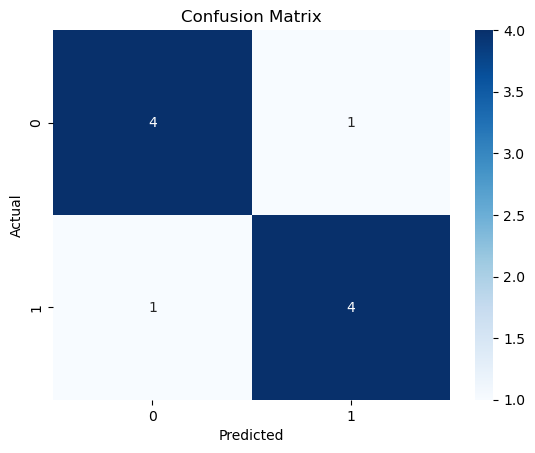

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# Interview Questions:
1. Can you explain the difference between user-based and item-based collaborative filtering?
2. What is collaborative filtering, and how does it work?

1. Difference Between User-Based and Item-Based Collaborative Filtering:
User-Based Collaborative Filtering:

Definition: This method recommends items to a user by finding users who are similar to them and suggesting items that those similar users have liked.
How It Works:
Step 1: Identify a target user.
Step 2: Find users who have similar preferences to the target user based on their past interactions (e.g., ratings, purchases).
Step 3: Recommend items that these similar users have liked or interacted with but that the target user has not yet interacted with.
Example: If two users both like the same genres of anime, the system may recommend an anime that one user has watched but the other hasn't.
Item-Based Collaborative Filtering:

Definition: This method recommends items by comparing the similarity between items themselves, rather than between users.
How It Works:
Step 1: Identify a target item that a user has interacted with.
Step 2: Find other items that are similar to this target item based on user interactions.
Step 3: Recommend these similar items to the user.
Example: If a user likes one particular anime, the system will recommend other anime that have similar ratings or genres, regardless of the preferences of other users.
Key Differences:

Focus: User-based focuses on the similarity between users, while item-based focuses on the similarity between items.
Scalability: Item-based filtering is often more scalable because items are typically fewer in number than users, making it easier to compute similarities.
Cold Start Problem: User-based filtering can struggle with the cold start problem for new users, while item-based filtering can struggle with new items.

    
2. What is Collaborative Filtering, and How Does It Work?
Collaborative Filtering:

Definition: Collaborative filtering is a method used by recommendation systems to make automatic predictions about the preferences of a user by collecting preferences from many users (collaboration).
Types:
User-Based Collaborative Filtering: Recommends items based on the preferences of similar users.
Item-Based Collaborative Filtering: Recommends items that are similar to other items the user has liked.
How It Works:

Data Collection: The system collects data on user-item interactions, such as ratings, purchases, or clicks.
Similarity Calculation: The system calculates similarity scores, either between users (user-based) or between items (item-based), using techniques like cosine similarity, Pearson correlation, etc.
Recommendation Generation:
User-Based: For a target user, the system finds similar users and recommends items they liked but the target user hasn’t interacted with.
Item-Based: For a target item that a user has interacted with, the system recommends similar items.
Advantages:
Personalization: Provides personalized recommendations.
Simplicity: Easy to implement and understand.
Challenges:
Cold Start Problem: Difficulties with new users or items that lack interaction data.
Data Sparsity: With large datasets, many users may have interacted with only a few items, leading to sparse data matrices.
Collaborative filtering is widely used in various recommendation systems, including those for movies, music, products, and more, due to its effectiveness in personalizing user experiences.






